In [1]:
import os
from pathlib import Path
from collections import defaultdict
import concurrent.futures
import pickle
os.chdir('../')


In [2]:
base_path = "./all_dos_data_full/all_dos_data_full"

In [3]:
# Dictionary to group files by their parent directory
file_groups = defaultdict(list)

# Load spin neutral samples instead of walking entire base_path
spin_neutral_pkl = 'spin_neutral.pkl' if os.path.exists('spin_neutral.pkl') else '../spin_neutral.pkl'
if os.path.exists(spin_neutral_pkl):
    with open(spin_neutral_pkl, 'rb') as f:
        spin_neutral_dirs = pickle.load(f)
    print(f"Loaded {len(spin_neutral_dirs)} directories from {spin_neutral_pkl}")
else:
    print(f"WARNING: {spin_neutral_pkl} not found. Searching base_path.")
    spin_neutral_dirs = [root for root, dirs, files in os.walk(base_path)]

# Walk through all directories
for root in spin_neutral_dirs:
    if os.path.exists(root):
        files = os.listdir(root)
        for file in files:
            if file in ['dos_DW', 'dos_UP', 'POSCAR']:
                # Get the parent directory (calculation directory)
                parent_dir = root
                file_path = os.path.join(root, file)
                file_groups[parent_dir].append((file, file_path))

# Create list of tuples with (dos_DW, dos_UP, POSCAR)
file_pairs = []
n = 0

def validate_files(files_dict):
    """Helper to validate files without reading the entire contents into memory."""
    try:
        # Check if files physically have data before opening
        if os.path.getsize(files_dict['dos_DW']) == 0 or os.path.getsize(files_dict['dos_UP']) == 0:
            return False
            
        # Just check the first non-empty line of each to ensure correct formatting
        for key in ['dos_DW', 'dos_UP']:
            with open(files_dict[key], 'r') as f:
                for line in f:
                    if line.strip():
                        # Verify we can extract the energy value successfully
                        float(line.split()[1])
                        break
        return True
    except (ValueError, IndexError, OSError) as e:
        return False

# Limit the number of directories processed simultaneously to manage memory
max_workers = os.cpu_count() or 4
print(f"Validating samples using {max_workers} threads...")

with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as executor:
    # Submit all validation tasks
    future_to_dict = {}
    for parent_dir, files in file_groups.items():
        # Ensure we have all three required files
        files_dict = {name: path for name, path in files}
        if 'dos_DW' in files_dict and 'dos_UP' in files_dict and 'POSCAR' in files_dict:
            future = executor.submit(validate_files, files_dict)
            future_to_dict[future] = files_dict
            
    # Collect results as they complete
    for future in concurrent.futures.as_completed(future_to_dict):
        if future.result():  # If validation passed
            files_dict = future_to_dict[future]
            file_pairs.append((
                files_dict['dos_DW'],
                files_dict['dos_UP'],
                files_dict['POSCAR']
            ))

print(f"Discovered {len(file_pairs)} fully valid sample calculation folders.")

Loaded 21556 directories from spin_neutral.pkl
Validating samples using 20 threads...
Discovered 21546 fully valid sample calculation folders.


In [4]:
import sys
import os
import random
import itertools
import util

import importlib

importlib.reload(util)

util.init_properties("properties.txt")


full_element_list = list(util.getPeriodicTableDict().keys())

full_list = [] 

for el in full_element_list:
    for n, orbital in  enumerate(util.getValenceInteractions(el)):
        full_list.append(f"{el}_{orbital}_{n+1}")

on_site_energies = {el: random.uniform(0.1, 10.0) for el in full_list}

hopping_energies = {}
# create a unique entry for every pair combination between the element-orbitals
for el1, el2 in itertools.combinations_with_replacement(full_list, 2):
    energy = random.uniform(0.1, 10.0)
    hopping_energies[(el1, el2)] = energy
    if el1 != el2:
        hopping_energies[(el2, el1)] = energy

In [ ]:
import numpy as np
import util

# Cache orbital generation per element to avoid repeating util function calls
# Since full_list is defined globally, we can precompute a cache of the orbitals for all known elements.
el_orbs_cache = {}
for el in util.getPeriodicTableDict().keys():
    try:
        el_orbs_cache[el] = [f"{el}_{orbital}_{n+1}" for n, orbital in enumerate(util.getValenceInteractions(el))]
    except KeyError:
        pass # Handle if some elements in util are missing from our potential data

def precompute_basis(elements):
    """
    Precompute the basis information for a specific structure to avoid re-evaluating 
    during bulk tight-binding generations.
    """
    atom_orbitals = [el_orbs_cache[el] for el in elements]
    basis_sizes = [len(orbs) for orbs in atom_orbitals]
    total_basis = sum(basis_sizes)
    basis_idx = np.insert(np.cumsum(basis_sizes), 0, 0)[:-1]
    
    return atom_orbitals, total_basis, basis_idx


# distance is approx 0-16 as the cell is 16.3 angtroms wide
def build_adj(file_tuple, threshold_distance=3.0):

    # The third value in the tuple is the POSCAR path
    poscar_path = file_tuple[2]
    
    with open(poscar_path, 'r') as f:
        lines = f.readlines()
        
    # Read the scaling factor and lattice vectors to compute true distances
    scale = float(lines[1].strip())
    lattice = np.array([
        [float(x) for x in lines[2].split()],
        [float(x) for x in lines[3].split()],
        [float(x) for x in lines[4].split()]
    ]) * scale
        
    # In VASP POSCAR, 6th line is element names (index 5)
    # 7th line is atom counts for each element (index 6)
    element_names = lines[5].split()
    element_counts = [int(x) for x in lines[6].split()]
    
    # Expand element names based on counts to get element type for each atom
    elements = []
    for name, count in zip(element_names, element_counts):
        elements.extend([name] * count)
        
    # Find where the coordinates start ("Direct" or "Cartesian" usually around line 8)
    coord_idx = 0
    while coord_idx < len(lines) and not lines[coord_idx].strip() in ["Direct", "Cartesian"]:
        coord_idx += 1
        
    # Determine the coordinate type
    coord_type = lines[coord_idx].strip()
    
    # Skip the "Direct" / "Cartesian" line
    coord_idx += 1
    
    # Read coordinates
    coords = []
    while coord_idx < len(lines):
        line = lines[coord_idx].strip()
        if not line:  # Stop at end of block
            break
        
        # Split line and extract first 3 float values
        parts = line.split()
        if len(parts) >= 3:
            coord = [float(parts[0]), float(parts[1]), float(parts[2])]
            coords.append(coord)
                
        coord_idx += 1
        
    coords = np.array(coords)
    
    # Calculate distance matrix with periodic boundary conditions
    # Broadcast to compute all pairwise differences: shape (N, N, 3)
    diffs = coords[:, np.newaxis, :] - coords[np.newaxis, :, :]
    
    if coord_type == "Direct":
        # Minimum image convention for fractional coordinates
        # Wraps differences robustly to [-0.5, 0.5]
        diffs = (diffs + 0.5) % 1.0 - 0.5
        
        # Convert fractional differences to Cartesian differences using lattice
        diffs = np.dot(diffs, lattice)
            
    # Compute the standard L2 norm (Euclidean distance) on Cartesian differences
    dist_matrix = np.linalg.norm(diffs, axis=-1)
    
    # Apply the threshold distance to form an adjacency matrix
    adj_matrix = (dist_matrix < threshold_distance).astype(int)
    
    # Set the diagonals to 0 (an atom shouldn't connect to itself)
    np.fill_diagonal(adj_matrix, 0)
    
    return adj_matrix, dist_matrix, elements

def build_hamiltonian(adj_matrix, dist_matrix, atom_orbitals, total_basis, basis_idx, on_site_energies, hopping_energies, decay_length=1.0):
    """
    Build a tight-binding Hamiltonian based on the adjacency matrix and distance matrix.
    The Hamiltonian size is determined by the total number of orbitals across all atoms.
    Diagonal elements (on-site energies) are set from the on_site_energies mapping.
    Orbitals match with other atoms based on hopping_energies, but DO NOT bond with
    other orbitals on the same atom.
    """

    decay_matrix = np.zeros_like(dist_matrix)
    mask = adj_matrix == 1
    decay_matrix[mask] = np.exp(-dist_matrix[mask] / decay_length)
    
    hamiltonian = np.zeros((total_basis, total_basis), dtype=np.float64)
    num_atoms = len(atom_orbitals)
    
    for i in range(num_atoms):
        orbs_i = atom_orbitals[i]
        start_i = basis_idx[i]
        
        # Set on-site energies (diagonal only, no intra-atom bonding)
        for idx, orb in enumerate(orbs_i):
            hamiltonian[start_i + idx, start_i + idx] = on_site_energies[orb]
            
        # Find all connections for atom i using numpy where instead of inner loop condition
        connected_j = np.where(adj_matrix[i, i+1:] == 1)[0] + i + 1
        
        for j in connected_j:
            d_factor = decay_matrix[i, j]
            orbs_j = atom_orbitals[j]
            start_j = basis_idx[j]
            
            for idx_i, orb_i in enumerate(orbs_i):
                # Pre-calculate row offset
                h_row = start_i + idx_i
                
                for idx_j, orb_j in enumerate(orbs_j):
                    # Hopping lookup
                    t0 = hopping_energies.get((orb_i, orb_j))
                    if t0 is None:
                        t0 = hopping_energies.get((orb_j, orb_i), 0.0)
                        
                    if t0 != 0.0:
                        t_ij = t0 * d_factor
                        h_col = start_j + idx_j
                        
                        hamiltonian[h_row, h_col] = t_ij
                        hamiltonian[h_col, h_row] = t_ij  # Symmetric
    
    return hamiltonian

# import time
# global_time_mse = 0.0

def compute_mse(energies, dos_energies):
    """
    Computes the Mean Squared Error (MSE) between the input eigenvalues 
    and the DOS energies by matching them element for element from lowest
    to highest. Truncates the longer array to match the shorter one.
    Assumes both arrays are ALREADY SORTED.
    """
    # global global_time_mse
    # t0 = time.time()
    
    min_len = min(len(energies), len(dos_energies))
    
    diffs = energies[:min_len] - dos_energies[:min_len]
    mse = np.mean(diffs ** 2)
    
    # global_time_mse += (time.time() - t0)
    return mse


In [ ]:
def compute_onsite_perturbation_grad(energies, eigen_functions, dos_energies, param_indices, base_mse, perturbation=1e-4):
    """
    Computes the gradient of the MSE with respect to a change in the on-site energy
    for a general parameter (e.g. Si_S_1) across all its occurrences in the Hamiltonian.
    """

    delta_energies = np.sum(np.abs(eigen_functions[param_indices, :]) ** 2, axis=0) * perturbation
    new_energies = energies + delta_energies
    
    new_mse = compute_mse(new_energies, dos_energies)
    
    # Calculate numerical gradient
    grad = (new_mse - base_mse) / perturbation
    
    return grad

def compute_hopping_perturbation_grad(energies, eigen_functions, dos_energies, row_indices, col_indices, decay_factors, base_mse, perturbation=1e-4):
    """
    Computes the gradient of the MSE with respect to a change in a hopping energy parameter.
    The parameters must supply the exact row/col pairs in the Hamiltonian and their corresponding
    distance decay factors, since hopping energies are scaled by distance: t_ij = t0 * decay.
    """
    # First-order perturbation: dE_n = <psi_n | dH | psi_n>
    # Since dH has symmetric non-zero entries at (row, col) and (col, row),
    # the shift is: 2 * Re(psi_i * psi_j) * decay_factor * perturbation.
    # Note: eigen_functions from `np.linalg.eigh` are real, so we just multiply them out.
    
    # Calculate energy shifts across all eigenstates
    # Broadcasting decay_factors into shape (num_pairs, 1) and multiplying by eigenfunctions
    shifts = 2 * eigen_functions[row_indices, :] * eigen_functions[col_indices, :] * decay_factors[:, np.newaxis]
    delta_energies = np.sum(shifts, axis=0) * perturbation
    
    new_energies = energies + delta_energies
    
    new_mse = compute_mse(new_energies, dos_energies)
    
    # Calculate numerical gradient with chain rule taking the exponential into account
    # Note: the effect of the exponential is inside delta_energies because 
    # we multiply `shifts` by `decay_factors` explicitly.
    grad = (new_mse - base_mse) / perturbation
    return grad

def precompute_onsite_topology(atom_orbitals, basis_idx):
    """
    Groups Hamiltonian parameter occurrences strictly once prior to training.
    """
    param_to_indices = {}
    for i, orbs in enumerate(atom_orbitals):
        start_i = basis_idx[i]
        for idx, orb in enumerate(orbs):
            if orb not in param_to_indices:
                param_to_indices[orb] = []
            param_to_indices[orb].append(start_i + idx)
            
    # Convert lists to numpy arrays for extremely fast broadcasting later
    return {orb: np.array(indices) for orb, indices in param_to_indices.items()}

def precompute_hopping_topology(adj_matrix, dist_matrix, atom_orbitals, basis_idx, decay_length=1.0):
    """
    Calculates spatial overlaps (decay factors) and index mappings for all hopping parameters
    so they do not have to be repeatedly matched up using double 'for' loops every epoch.
    """
    decay_matrix = np.zeros_like(dist_matrix)
    mask = adj_matrix == 1
    decay_matrix[mask] = np.exp(-dist_matrix[mask] / decay_length)
    
    param_to_instances = {}
    num_atoms = len(atom_orbitals)
    
    for i in range(num_atoms):
        orbs_i = atom_orbitals[i]
        start_i = basis_idx[i]
        connected_j = np.where(adj_matrix[i, i+1:] == 1)[0] + i + 1
        
        for j in connected_j:
            d_factor = decay_matrix[i, j]
            orbs_j = atom_orbitals[j]
            start_j = basis_idx[j]
            
            for idx_i, orb_i in enumerate(orbs_i):
                h_row = start_i + idx_i
                
                for idx_j, orb_j in enumerate(orbs_j):
                    h_col = start_j + idx_j
                    
                    param = tuple(sorted([orb_i, orb_j])) # canonize naming
                    if param not in param_to_instances:
                        param_to_instances[param] = {"rows": [], "cols": [], "decays": []}
                        
                    param_to_instances[param]["rows"].append(h_row)
                    param_to_instances[param]["cols"].append(h_col)
                    param_to_instances[param]["decays"].append(d_factor)
                    
    # Convert all gathered lists to numpy arrays for matrix operations in gradient phase
    for param in param_to_instances:
        param_to_instances[param]["rows"] = np.array(param_to_instances[param]["rows"])
        param_to_instances[param]["cols"] = np.array(param_to_instances[param]["cols"])
        param_to_instances[param]["decays"] = np.array(param_to_instances[param]["decays"])
        
    return param_to_instances

def fast_onsite_grads(energies, eigen_functions, dos_energies, onsite_topology, base_mse, perturbation=1e-4):
    grads = {}
    for orb, indices in onsite_topology.items():
        grads[orb] = compute_onsite_perturbation_grad(
            energies, eigen_functions, dos_energies, indices, base_mse, perturbation
        )
    return grads

def fast_hopping_grads(energies, eigen_functions, dos_energies, hopping_topology, base_mse, perturbation=1e-4):
    grads = {}
    for param, data in hopping_topology.items():
        grad = compute_hopping_perturbation_grad(
            energies, eigen_functions, dos_energies, 
            data["rows"], data["cols"], data["decays"], 
            base_mse, perturbation
        )
        grads[param] = grad
    return grads


In [ ]:
# Reset environment variables to their default behavior (allowing multithreading) for the sequential loop
import os
for var in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"]:
    if var in os.environ:
        del os.environ[var]

# Create our training loop (CPU Sequential)
import time
from tqdm.auto import tqdm
import numpy as np
import pickle

# Training hyperparameters
learning_rate = 0.05
epochs = 10
decay_length = 1.0
perturbation = 1e-4

distance_threshold = 4.5

print("Precomputing data...")
num_samples = min(1000, len(file_pairs))
precomputed_data = []

for i in range(num_samples):
    file_tuple = file_pairs[i]
    # Load Dos DW values
    with open(file_tuple[0], 'r') as f:
        dos_energies = np.array([float(line.split()[1]) for line in f if line.strip()])
 
    # Precompute positional information
    adj_mat, dist_mat, elems = build_adj(file_tuple, threshold_distance=distance_threshold)
    atom_orbs, t_basis, b_idx = precompute_basis(elems)
    
    # Precalculate massive topology operations only one time here!
    onsite_top = precompute_onsite_topology(atom_orbs, b_idx)
    hopping_top = precompute_hopping_topology(adj_mat, dist_mat, atom_orbs, b_idx, decay_length)
    
    precomputed_data.append({
        'dos_energies': dos_energies,
        'adj_matrix': adj_mat,
        'dist_matrix': dist_mat,
        'atom_orbitals': atom_orbs,
        'total_basis': t_basis,
        'basis_idx': b_idx,
        'onsite_topology': onsite_top,
        'hopping_topology': hopping_top,
        'name': file_tuple[0]  # Just to display name if needed
    })

print(f"Starting CPU Sequential training on {len(precomputed_data)} samples over {epochs} epochs...")

# The training loop
for epoch in range(epochs):
    epoch_mse = 0.0
    start_time = time.time()
    
    # # Profiling accumulators
    # time_build = 0.0
    # time_eigh = 0.0
    # time_onsite = 0.0
    # time_hopping = 0.0
    # time_update = 0.0
    # global_time_mse = 0.0 
    
    # Progress bar for the inner loop
    for i, data in enumerate(tqdm(precomputed_data, desc=f"Epoch {epoch+1}/{epochs}", leave=False)):
        
        # 1. Forward Pass: Build Hamiltonian on CPU
        # t0 = time.time()
        hamiltonian = build_hamiltonian(
            data['adj_matrix'], 
            data['dist_matrix'], 
            data['atom_orbitals'], 
            data['total_basis'], 
            data['basis_idx'], 
            on_site_energies, 
            hopping_energies, 
            decay_length
        )
        # t1 = time.time()
        # time_build += (t1 - t0)
        
        # 2. Diagonalize purely on the CPU using Numpy (implicitly uses OpenBLAS/MKL threading)
        energies, eigen_functions = np.linalg.eigh(hamiltonian)
        # t2 = time.time()
        # time_eigh += (t2 - t1)
        
        # 3. Compute loss on CPU 
        base_mse = compute_mse(energies, data['dos_energies'])
        epoch_mse += base_mse
        # t3 = time.time()
        
        # 4. Backward Pass: Gradients on CPU
        # start_onsite_mse_time = global_time_mse
        onsite_grads = fast_onsite_grads(
            energies, eigen_functions, data['dos_energies'], 
            data['onsite_topology'], 
            base_mse, perturbation
        )
        # t4 = time.time()
        # time_onsite += (t4 - t3) - (global_time_mse - start_onsite_mse_time)
        
        # start_hopping_mse_time = global_time_mse
        hopping_grads = fast_hopping_grads(
            energies, eigen_functions, data['dos_energies'], 
            data['hopping_topology'], 
            base_mse, perturbation
        )
        # t5 = time.time()
        # time_hopping += (t5 - t4) - (global_time_mse - start_hopping_mse_time)
        
        # 5. Gradient Descent Updates
        for orb, grad in onsite_grads.items():
            on_site_energies[orb] -= learning_rate * grad
            
        for param, grad in hopping_grads.items():
            orb_i, orb_j = param
            hopping_energies[(orb_i, orb_j)] -= learning_rate * grad
            if orb_i != orb_j:
                hopping_energies[(orb_j, orb_i)] -= learning_rate * grad
        
        # t6 = time.time()
        # time_update += (t6 - t5)
                
    avg_mse = epoch_mse / len(precomputed_data)
    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{epochs} | Avg MSE: {avg_mse:.6f} | Time: {elapsed:.2f}s")
    
    # total_tracked = time_build + time_eigh + global_time_mse + time_onsite + time_hopping + time_update
    # if total_tracked > 0:
    #     print(f"  - build_hamiltonian:    {time_build/total_tracked*100:.1f}%")
    #     print(f"  - np.linalg.eigh: {time_eigh/total_tracked*100:.1f}%")
    #     print(f"  - compute_mse:          {global_time_mse/total_tracked*100:.1f}%")
    #     print(f"  - onsite_grads:         {time_onsite/total_tracked*100:.1f}%")
    #     print(f"  - hopping_grads:        {time_hopping/total_tracked*100:.1f}%")
    #     print(f"  - gradient_updates:     {time_update/total_tracked*100:.1f}%")

print("Training finished.")

# Save the updated parameters
with open('trained_onsite_energies.pkl', 'wb') as f:
    pickle.dump(on_site_energies, f)
    
with open('trained_hopping_energies.pkl', 'wb') as f:
    pickle.dump(hopping_energies, f)

print("Saved trained parameters to 'trained_onsite_energies.pkl' and 'trained_hopping_energies.pkl'")

Precomputing data...
Starting CPU Sequential training on 1000 samples over 10 epochs...


Epoch 1/10:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/10 | Avg MSE: 2.981792 | Time: 216.17s


Epoch 2/10:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2/10 | Avg MSE: 1.733039 | Time: 209.24s


...

Epoch 8/10 | Avg MSE: 1.380601 | Time: 231.99s


Epoch 9/10:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 9/10 | Avg MSE: 1.376272 | Time: 225.20s


Epoch 10/10:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 10/10 | Avg MSE: 1.373208 | Time: 229.31s
Training finished.
Saved trained parameters to 'trained_onsite_energies.pkl' and 'trained_hopping_energies.pkl'


In [ ]:
# Set environment variables to restrict NumPy to a single thread per process
# This must be done to prevent thread-thrashing when multiprocessing/multithreading
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

# Create our training loop
import time
from tqdm.auto import tqdm
import concurrent.futures
from functools import partial
import pickle

# Training hyperparameters
learning_rate = 0.1
epochs = 10
decay_length = 1.0
perturbation = 1e-4

temp = []

print("Precomputing data to speed up training...")
# Limit to the first 5 file pairs for faster test training (can configure later)
num_samples = min(1000, len(file_pairs))
precomputed_data = []

for i in range(num_samples):
    file_tuple = file_pairs[i]
    # Load Dos DW values
    with open(file_tuple[0], 'r') as f:
        dos_energies = np.array([float(line.split()[1]) for line in f if line.strip()])
 
    # Precompute positional information
    adj_mat, dist_mat, elems = build_adj(file_tuple, threshold_distance=3.0)
    atom_orbs, t_basis, b_idx = precompute_basis(elems)
    
    # Precalculate massive topology operations only one time here!
    onsite_top = precompute_onsite_topology(atom_orbs, b_idx)
    hopping_top = precompute_hopping_topology(adj_mat, dist_mat, atom_orbs, b_idx, decay_length)
    
    precomputed_data.append({
        'dos_energies': dos_energies,
        'adj_matrix': adj_mat,
        'dist_matrix': dist_mat,
        'atom_orbitals': atom_orbs,
        'total_basis': t_basis,
        'basis_idx': b_idx,
        'onsite_topology': onsite_top,
        'hopping_topology': hopping_top,
        'name': file_tuple[0]  # Just to display name if needed
    })

print(f"Starting training on {len(precomputed_data)} samples over {epochs} epochs...")

# Worker function for parallel execution
def process_sample(data, current_onsite_energies, current_hopping_energies, decay_len, pert):
    
    # 1. Forward Pass: Build Hamiltonian
    hamiltonian = build_hamiltonian(
        data['adj_matrix'], 
        data['dist_matrix'], 
        data['atom_orbitals'], 
        data['total_basis'], 
        data['basis_idx'], 
        current_onsite_energies, 
        current_hopping_energies, 
        decay_len
    )
    
    # 2. Diagonalize
    energies, eigen_functions = np.linalg.eigh(hamiltonian)
    
    # 3. Compute loss
    base_mse = compute_mse(energies, data['dos_energies'])
    
    # 4. Backward Pass: Gradients
    onsite_grads = fast_onsite_grads(
        energies, eigen_functions, data['dos_energies'], 
        data['onsite_topology'], 
        base_mse, pert
    )
    
    hopping_grads = fast_hopping_grads(
        energies, eigen_functions, data['dos_energies'], 
        data['hopping_topology'], 
        base_mse, pert
    )
    
    return base_mse, onsite_grads, hopping_grads

# Set up executor
num_workers = os.cpu_count()

# The training loop
for epoch in range(epochs):
    epoch_mse = 0.0
    start_time = time.time()
    
    # Use ThreadPoolExecutor instead of ProcessPoolExecutor!
    # NumPy releases the Python GIL during heavy math (like np.linalg.eigh and matrix multiplication).
    # Threads share memory, so we avoid the massive IPC (Inter-Process Communication) overhead of pickling dictionaries and matrices.
    with concurrent.futures.ThreadPoolExecutor(max_workers=num_workers) as executor:
        futures = {}
        data_iter = iter(precomputed_data)
        
        # Helper to submit the next task with the absolute latest parameters
        def submit_next():
            try:
                data = next(data_iter)
                # Pass a copy of the CURRENT parameters so the worker sees the latest SGD step
                # With threads, copying these small dicts is instant, and `data` is passed by reference (no pickling overhead!).
                future = executor.submit(process_sample, data, on_site_energies.copy(), hopping_energies.copy(), decay_length, perturbation)
                futures[future] = data
                return True
            except StopIteration:
                return False

        # Pre-fill the execution queue with one task per worker core
        for _ in range(num_workers):
            submit_next()
            
        with tqdm(total=len(precomputed_data), desc=f"Epoch {epoch+1}/{epochs}", leave=False) as pbar:
            while futures:
                # Wait for the very first worker to finish
                done, _ = concurrent.futures.wait(futures.keys(), return_when=concurrent.futures.FIRST_COMPLETED)
                
                for future in done:
                    del futures[future]
                    base_mse, o_grads, h_grads = future.result()
                    epoch_mse += base_mse
                    
                    # SGD Updates - Apply immediately!
                    for orb, grad in o_grads.items():
                        on_site_energies[orb] -= learning_rate * grad
                        
                    for param, grad in h_grads.items():
                        orb_i, orb_j = param
                        hopping_energies[(orb_i, orb_j)] -= learning_rate * grad
                        if orb_i != orb_j:
                            hopping_energies[(orb_j, orb_i)] -= learning_rate * grad
                            
                    # Submit the next task immediately so it uses the newly updated parameters
                    submit_next()
                    pbar.update(1)
                
    avg_mse = epoch_mse / len(precomputed_data)
    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{epochs} | Avg MSE: {avg_mse:.6f} | Time: {elapsed:.2f}s")

print("Training finished.")

# Save the updated parameters
with open('trained_onsite_energies.pkl', 'wb') as f:
    pickle.dump(on_site_energies, f)
    
with open('trained_hopping_energies.pkl', 'wb') as f:
    pickle.dump(hopping_energies, f)

print("Saved trained parameters to 'trained_onsite_energies.pkl' and 'trained_hopping_energies.pkl'")

Precomputing data to speed up training...
Starting training on 1000 samples over 45 epochs...


Epoch 1/45:   0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

Testing on sample: ./all_dos_data_full/all_dos_data_full/001296_H-sSi_Sn-i/pbem1_gs_relax/dos_DW



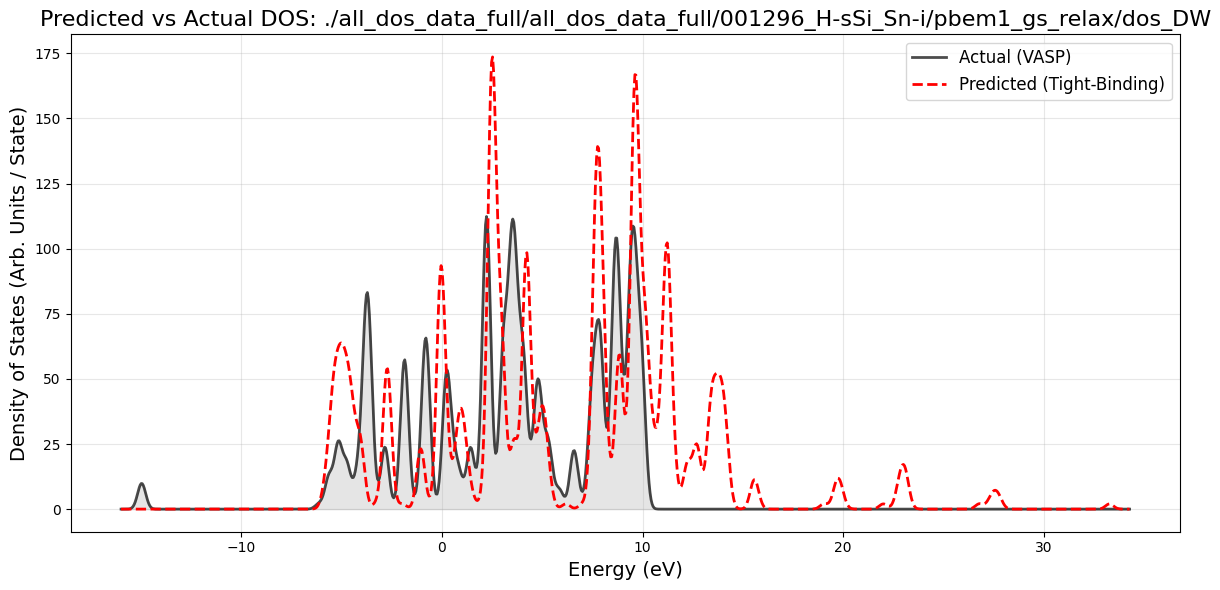

In [ ]:
import random

# Select a random sample from our precomputed training data
sample_idx = random.randint(0, len(precomputed_data) - 1)
test_data = precomputed_data[sample_idx]

print(f"Testing on sample: {test_data['name']}\n")

# Build the Hamiltonian with our newly trained parameters
test_hamiltonian = build_hamiltonian(
    test_data['adj_matrix'], 
    test_data['dist_matrix'], 
    test_data['atom_orbitals'], 
    test_data['total_basis'], 
    test_data['basis_idx'], 
    on_site_energies, 
    hopping_energies, 
    decay_length
)

# Diagonalize to get computed energies
computed_energies, _ = np.linalg.eigh(test_hamiltonian)
actual_energies = test_data['dos_energies']

import matplotlib.pyplot as plt

def gaussian_smearing(energies, e_regime, sigma=0.1):
    """Applies Gaussian broadening to discrete energy levels to generate a continuous DOS curve."""
    dos = np.zeros_like(e_regime)
    for e in energies:
        dos += np.exp(-0.5 * ((e_regime - e) / sigma)**2) / (sigma * np.sqrt(2 * np.pi))
    return dos

# Define the energy range for plotting based on the min and max eigenvalues
min_e = min(np.min(computed_energies), np.min(actual_energies)) - 1.0
max_e = max(np.max(computed_energies), np.max(actual_energies)) + 1.0
e_regime = np.linspace(min_e, max_e, 1000)

# Apply smearing to create the DOS curves (sigma acts as the broadening width)
# Scaling down by the total sample count length
sigma_smearing = .2
actual_dos = gaussian_smearing(actual_energies, e_regime, sigma=sigma_smearing)
computed_dos = gaussian_smearing(computed_energies, e_regime, sigma=sigma_smearing)

# Plot the DOS
plt.figure(figsize=(12, 6))
plt.plot(e_regime, actual_dos, label='Actual (VASP)', color='black', alpha=0.7, linewidth=2)
plt.plot(e_regime, computed_dos, label='Predicted (Tight-Binding)', color='red', linestyle='--', linewidth=2)

# Shade the overlap for visibility
plt.fill_between(e_regime, actual_dos, color='gray', alpha=0.2)

plt.xlabel('Energy (eV)', fontsize=14)
plt.ylabel('Density of States (Arb. Units / State)', fontsize=14)
plt.title(f'Predicted vs Actual DOS: {test_data["name"]}', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()